<a href="https://colab.research.google.com/github/demsaid400-cpu/DI-BOOTCAMP/blob/main/Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import zipfile
import os

zip_path = '/content/Basics of BERT and XLM-RoBERTa - PyTorch - 2.zip'
extract_path = '/content/basics_bert_xlm'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Extracted files to: {extract_path}')
os.listdir(extract_path)

Extracted files to: /content/basics_bert_xlm


['Basics of BERT and XLM-RoBERTa - PyTorch']

In [ ]:
from transformers import BertTokenizer
from transformers import XLMRobertaTokenizer

bert_tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

xlm_tokenizer = XLMRobertaTokenizer.from_pretrained(
    "xlm-roberta-base"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

In [ ]:
from transformers import BertTokenizer

# Re-instantiating to ensure the object is correctly initialized
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
sentence = "I love learning Deep Learning."

# Recommended way to encode in modern transformers
encoding = tokenizer(
    sentence,
    add_special_tokens=True,
    max_length=32,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

print(encoding)

{'input_ids': tensor([[ 101, 1045, 2293, 4083, 2784, 4083, 1012,  102,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]]), 'token_type_ids': tensor([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])}


In [ ]:
import zipfile
import os

# Unzipping the challenge data
for filename in ["train.csv.zip", "test.csv.zip"]:
    file_path = os.path.join(nested_path, filename)
    with zipfile.ZipFile(file_path, "r") as zip_ref:
        zip_ref.extractall(nested_path)

print("Extracted datasets:")
print([f for f in os.listdir(nested_path) if f.endswith(".csv")])

Extracted datasets:
['train.csv', 'test.csv', 'sample_submission.csv']


In [ ]:
print("Input IDs:")
print(encoding["input_ids"])

print("\nAttention Mask:")
print(encoding["attention_mask"])

Input IDs:
tensor([[ 101, 1045, 2293, 4083, 2784, 4083, 1012,  102,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
            0,    0,    0,    0,    0,    0,    0,    0]])

Attention Mask:
tensor([[1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0]])


In [ ]:
decoded = bert_tokenizer.decode(
    encoding["input_ids"]
)

print(decoded)

['[CLS] i love learning deep learning. [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]']


In [ ]:
import pandas as pd

train_df = pd.read_csv(os.path.join(nested_path, 'train.csv'))
print("Dataset Shape:", train_df.shape)
train_df.head()

Dataset Shape: (12120, 6)


,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


In [ ]:
from transformers import BertTokenizer

# Re-initializing for a clean state
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

sentence = 'I love learning Deep Learning.'

# Using the __call__ method (recommended)
encoding = tokenizer(
    sentence,
    add_special_tokens=True,
    max_length=128,
    padding='max_length',
    truncation=True,
    return_attention_mask=True,
    return_tensors='pt'
)

print('Encoding successful!')
print(f'Keys in encoding: {list(encoding.keys())}')
print(f'Input IDs shape: {encoding["input_ids"].shape}')

Encoding successful!
Keys in encoding: ['input_ids', 'token_type_ids', 'attention_mask']
Input IDs shape: torch.Size([1, 128])


In [ ]:
import pandas as pd

train_df = pd.read_csv(os.path.join(nested_path, 'train.csv'))
print("Dataset Shape:", train_df.shape)
train_df.head()

Dataset Shape: (12120, 6)


,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


In [ ]:
print(
    bert_tokenizer.special_tokens_map
)

{'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}


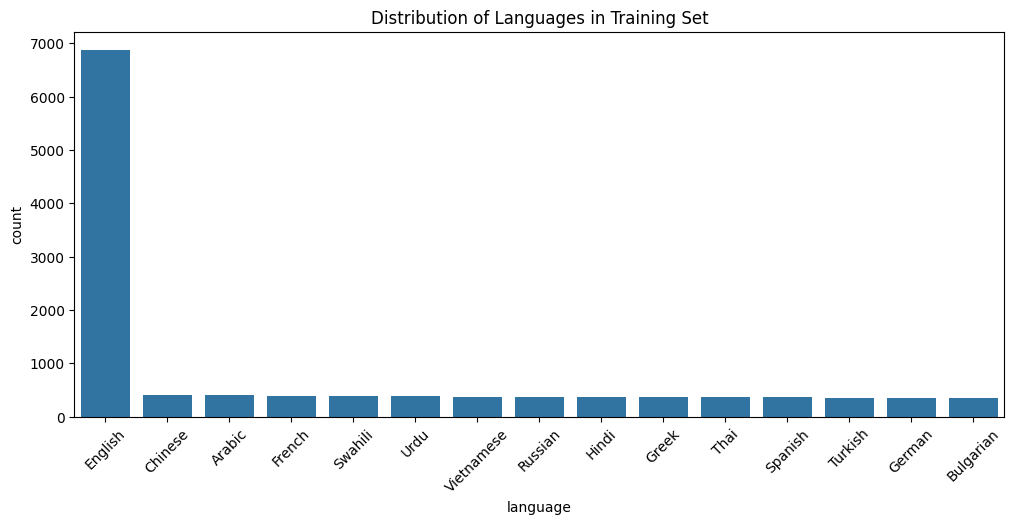

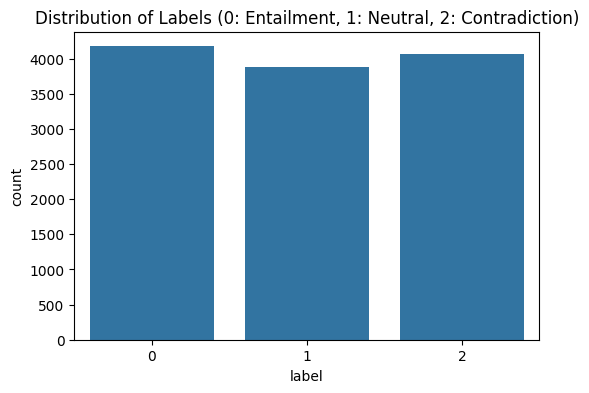

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize language distribution
plt.figure(figsize=(12, 5))
sns.countplot(data=train_df, x='language', order=train_df['language'].value_counts().index)
plt.title('Distribution of Languages in Training Set')
plt.xticks(rotation=45)
plt.show()

# Visualize label distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='label')
plt.title('Distribution of Labels (0: Entailment, 1: Neutral, 2: Contradiction)')
plt.show()

In [ ]:
import pandas as pd
import os

# The files are located in the nested_path defined earlier
train_df = pd.read_csv(
    os.path.join(nested_path, "train.csv")
)

test_df = pd.read_csv(
    os.path.join(nested_path, "test.csv")
)

print("Data loaded successfully from:", nested_path)

Data loaded successfully from: /content/basics_bert_xlm/Basics of BERT and XLM-RoBERTa - PyTorch


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification

# Initialize the multilingual tokenizer
model_name = 'xlm-roberta-base'
tokenizer = XLMRobertaTokenizer.from_pretrained(model_name)

class NLIDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):
        premise = str(self.df.loc[index, 'premise'])
        hypothesis = str(self.df.loc[index, 'hypothesis'])
        label = self.df.loc[index, 'label']

        encoding = self.tokenizer(
            premise,
            hypothesis,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Prepare DataLoaders
train_dataset = NLIDataset(train_df, tokenizer)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print(f'Created DataLoader with {len(train_loader)} batches.')

Created DataLoader with 758 batches.


In [ ]:
train_df.head()

,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


In [ ]:
print(train_df.shape)
print(test_df.shape)

(12120, 6)
(5195, 5)


In [ ]:
print(
    train_df.columns
)

Index(['id', 'premise', 'hypothesis', 'lang_abv', 'language', 'label'], dtype='object')


In [ ]:
# The dataset uses 'premise' and 'hypothesis' instead of 'text'
X_premise = train_df['premise']
X_hypothesis = train_df['hypothesis']
y = train_df['label']

print(f'Features and labels assigned successfully.')
print(f'Sample premise: {X_premise[0]}')

Features and labels assigned successfully.
Sample premise: and these comments were considered in formulating the interim rules.


In [ ]:
from sklearn.model_selection import (
    StratifiedKFold
)

In [ ]:
kf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
train_folds = []
valid_folds = []

# Using train_df as the feature set for splitting indices
for train_idx, valid_idx in kf.split(train_df, y):
    train_folds.append(train_idx)
    valid_folds.append(valid_idx)

print(f'Successfully created {len(train_folds)} folds.')

Successfully created 5 folds.


In [ ]:
MAX_LEN = 128
encoded_texts = []

# Loop through the dataframe to get both premise and hypothesis
# We use the 'tokenizer' object initialized in previous cells
for i in range(len(train_df)):
    premise = str(train_df.loc[i, 'premise'])
    hypothesis = str(train_df.loc[i, 'hypothesis'])

    # Encode both sentences together as a pair
    encoded = tokenizer(
        premise,
        hypothesis,
        max_length=MAX_LEN,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

    encoded_texts.append(encoded)

print(f'Successfully encoded {len(encoded_texts)} sentence pairs.')

Successfully encoded 12120 sentence pairs.


In [ ]:
from transformers import XLMRobertaForSequenceClassification, AdamW

# 1. Configuration du modèle
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = XLMRobertaForSequenceClassification.from_pretrained(model_name, num_labels=3)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)

print(f'Modèle chargé sur : {device}')

### Entraînement rapide (1 époque)
Pour l'exercice, nous allons entraîner sur une époque pour valider le flux.

In [46]:
import torch
from torch.optim import AdamW

# Ensure optimizer is defined with the correct PyTorch import
if 'optimizer' not in globals():
    optimizer = AdamW(model.parameters(), lr=2e-5)

model.train()
for batch in train_loader:
    optimizer.zero_grad()

    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)

    outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
    loss = outputs.loss
    loss.backward()
    optimizer.step()

print("Entraînement terminé.")

Entraînement terminé.


### Prédictions finales pour soumission

In [47]:
import torch
import pandas as pd
from torch.utils.data import Dataset, DataLoader

# Nous utilisons l'objet 'model' et 'device' déjà entraînés dans la cellule précédente
# au lieu de recharger un modèle vierge.

class NLITestDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len
    def __len__(self): return len(self.df)
    def __getitem__(self, i):
        encoding = self.tokenizer(str(self.df.loc[i, 'premise']), str(self.df.loc[i, 'hypothesis']),
                                  max_length=self.max_len, padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': encoding['input_ids'].flatten(), 'attention_mask': encoding['attention_mask'].flatten()}

test_dataset = NLITestDataset(test_df, tokenizer)
test_loader = DataLoader(test_dataset, batch_size=16)

model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        outputs = model(ids, attention_mask=mask)
        preds = torch.argmax(outputs.logits, dim=1)
        predictions.extend(preds.cpu().numpy())

submission = pd.DataFrame({'id': test_df['id'], 'prediction': predictions})
submission.to_csv('submission.csv', index=False)
print("Fichier submission.csv généré avec le modèle entraîné !")

Fichier submission.csv généré avec le modèle entraîné !


In [43]:
from google.colab import files

# Download the submission file to your local machine
files.download('submission.csv')
print("Submission file download triggered.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Submission file download triggered.
